<a href="https://colab.research.google.com/github/Dev-Arhaan/adaptive-edge-iot/blob/main/analyze_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# Cell 1
# !git clone https://github.com/Dev-Arhaan/adaptive-edge-iot.git
import pandas as pd

df = pd.read_csv("adaptive-edge-iot/ml/data/experiment_results.csv")
df

,scenario_name,scheduler_name,node_count,duration_ticks,wall_clock_seconds,total_wakes,emergency_wakes,emergency_broadcasts,average_interval_seconds,average_final_battery,nodes_dead,ignition_tick,first_emergency_tick,detection_latency_ticks
0,low_risk,fixed_dtc_baseline,150,1440,1.556352,43200,0,0,300.000000,83.29600,0,NaN,NaN,NaN
1,low_risk,adaptive_rule_based,150,1440,0.917235,21600,0,0,600.000000,90.20800,0,NaN,NaN,NaN
2,low_risk,adaptive_ml,150,1440,26.085768,21667,0,0,598.698482,90.18656,0,NaN,NaN,NaN
3,medium_risk,fixed_dtc_baseline,150,1440,1.669840,43200,0,0,300.000000,83.29600,0,NaN,NaN,NaN
4,medium_risk,adaptive_rule_based,150,1440,1.711609,42934,0,0,301.858667,83.38112,0,NaN,NaN,NaN
5,medium_risk,adaptive_ml,150,1440,50.175212,43198,0,0,300.013890,83.29664,0,NaN,NaN,NaN
6,wildfire,fixed_dtc_baseline,150,1440,1.558312,43200,1027,0,300.000000,83.29600,0,537.0,655.0,118.0
7,wildfire,adaptive_rule_based,150,1440,2.527319,64110,5145,29864,377.971455,76.60480,0,537.0,653.0,116.0
8,wildfire,adaptive_ml,150,1440,77.078385,63872,4122,23923,300.820078,76.68096,0,537.0,658.0,121.0
9,large_scale,adaptive_rule_based,600,1440,8.922870,254151,12343,130790,380.517842,76.78792,0,587.0,704.0,117.0


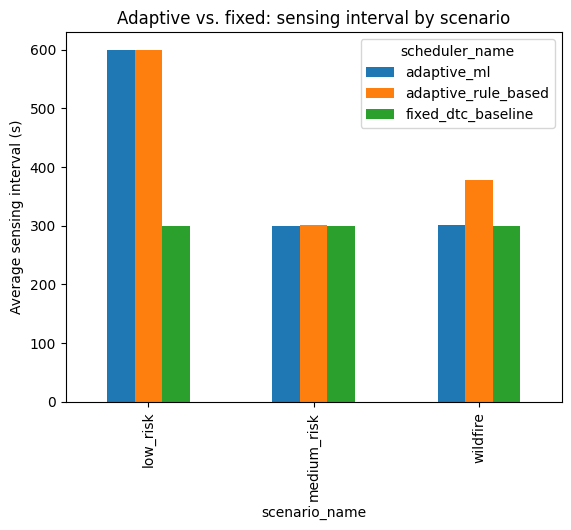

In [10]:
# Cell 2 — average interval by scenario/scheduler: the headline
# "adaptive is more vigilant when it matters, lazier when it's safe" result
import matplotlib.pyplot as plt

pivot = df[df["scenario_name"].isin(["low_risk", "medium_risk", "wildfire"])].pivot(
    index="scenario_name", columns="scheduler_name", values="average_interval_seconds"
)
pivot.plot(kind="bar")
plt.ylabel("Average sensing interval (s)")
plt.title("Adaptive vs. fixed: sensing interval by scenario")
plt.show()

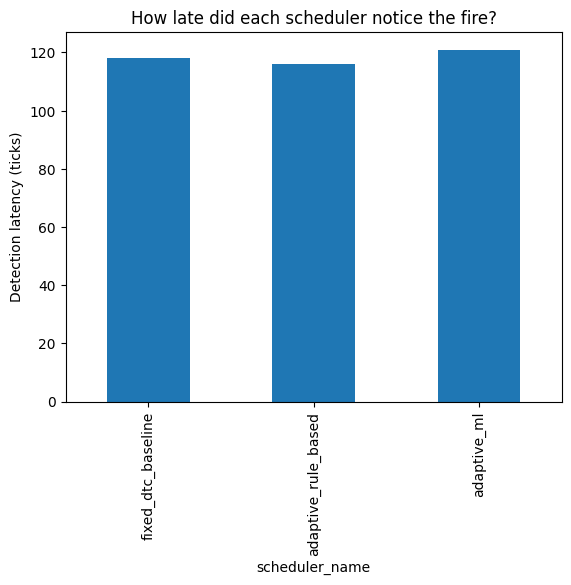

In [11]:
# Cell 3 — detection latency for the wildfire scenario
wildfire = df[df["scenario_name"] == "wildfire"][["scheduler_name", "detection_latency_ticks"]]
wildfire.plot(x="scheduler_name", y="detection_latency_ticks", kind="bar", legend=False)
plt.ylabel("Detection latency (ticks)")
plt.title("How late did each scheduler notice the fire?")
plt.show()

In [12]:
# Cell 4 — stress test: wall-clock scaling
scale_rows = df[df["scenario_name"].isin(["large_scale", "stress_test"])]
scale_rows[["scenario_name", "node_count", "wall_clock_seconds"]]

,scenario_name,node_count,wall_clock_seconds
9,large_scale,600,8.922870
10,stress_test,1200,34.834813
